Imports and Initialization

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA, KernelPCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import random

In [3]:
import kagglehub

In [4]:
np.random.seed(0)
random.seed(0)

In [5]:
path = kagglehub.dataset_download("nikhiljohnk/tweets-with-sarcasm-and-irony")

In [6]:
train = pd.read_csv(path+'/train.csv')
train.head(5)

,tweets,class
0,Be aware dirty step to get money #staylight ...,figurative
1,#sarcasm for #people who don't understand #diy...,figurative
2,@IminworkJeremy @medsingle #DailyMail readers ...,figurative
3,@wilw Why do I get the feeling you like games?...,figurative
4,-@TeacherArthurG @rweingarten You probably jus...,figurative


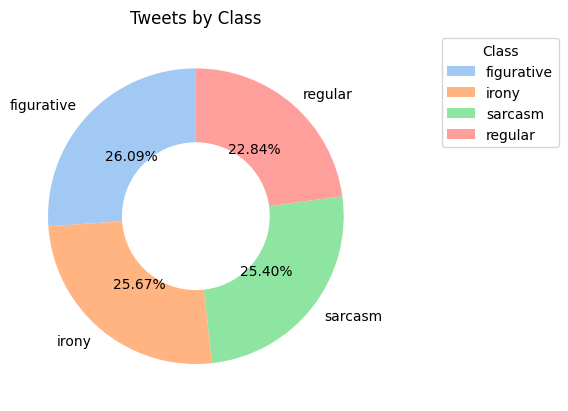

In [7]:
labels_class = (train['class'].value_counts()).index
colors = sns.color_palette('pastel')

fig, ax = plt.subplots()

wedges, texts, autotexts = ax.pie(
    train['class'].value_counts(),
    labels=labels_class,
    colors=colors,
    startangle=90,
    autopct='%1.2f%%',
    wedgeprops=dict(width=0.5)
)

ax.legend(wedges, labels_class, title="Class", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('Tweets by Class')
plt.show()


In [8]:
test = pd.read_csv(path+'/test.csv')
test.head(5)

,tweets,class
0,no one ever predicted this was going to happen...,figurative
1,@Stooshie its as closely related as Andrews or...,figurative
2,I find it ironic when Vegans say they love foo...,figurative
3,Quick rt that throwing money vine I've not see...,figurative
4,"yep, keep adding me to your #devops lists.... ...",figurative


NLP Toolkit

In [9]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords          # module for stop words that come with NLTK
from nltk.stem import PorterStemmer,WordNetLemmatizer         # module for stemming
from nltk.tokenize import TweetTokenizer,sent_tokenize,word_tokenize   # module for tokenizing strings

import re                                  # library for regular expression operations
import string                              # for string operations

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/anantshri/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/anantshri/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [10]:
# tweet preprocessing #
def preprocess_tweets(tweet):
    # cleans the tweet after removing extra stop words, punctuation etc. After this, the tweet needs to be tokenized, into words & then words converted into their respective lemma
    tweets_clean = []
    
    # Instantiate stemming class
    Lemma = WordNetLemmatizer()
    
    # Create an empty list to store the stems
    tweets_lemma = []

    stopwords_english = stopwords.words('english') 
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,reduce_len=True)
    
    tweet2 = re.sub(r'^RT[\s]+', '', tweet)
    # remove hyperlinks
    tweet2 = re.sub(r'https?:\/\/.*[\r\n]*', '', tweet2)
    
    tweet2 = re.sub(r'#', '', tweet2)   # remove hashtags
    
    tweet2 = re.sub(r"@\w+","", tweet2)        # remove mentions
    

    tweet_tokens = tokenizer.tokenize(tweet2)
    
    for word_token in tweet_tokens:
        if(word_token not in stopwords_english and word_token not in string.punctuation):
            stem_word = Lemma.lemmatize(word_token)
            tweets_clean.append(stem_word)
    
    return tweets_clean

In [11]:
train.tweets.apply(preprocess_tweets)

0        [aware, dirty, step, get, money, staylight, st...
1            [sarcasm, people, understand, diy, artattack]
2        [dailymail, reader, sensible, always, shocker,...
3                      [get, feeling, like, game, sarcasm]
4                      [probably, missed, text, sarcastic]
                               ...                        
81403                           [photo, image, via, heart]
81404    [never, knew, .., better, put, universe, lol, ...
81405    [hey, wanted, say, thanks, puberty, letting, a...
81406    [sure, coverage, like, fox, news, special, “, ...
81407               [u13, believe, see, ..., :-P, sarcasm]
Name: tweets, Length: 81408, dtype: object

In [12]:
le = LabelEncoder()
train['class'] = le.fit_transform(train['class'])

In [13]:
X_train, X_test, y_train, y_test = train_test_split(train['tweets'], train['class'],
                                               test_size = 0.20, stratify = train['class'],
                                               random_state = 0)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [14]:
def build_freq(tweets,label):
    ys = label
    yslist = np.squeeze(ys).tolist()

    freq = {}

    for tweet,y in zip(tweets,ys):
        for word in preprocess_tweets(tweet):
            pair = (word,y)
            if pair in freq:
                freq[pair] += 1
            else:
                freq[pair] = 1
    return freq

freqs = build_freq(X_train, y_train)

In [15]:
def extract_feature_map_multiclass(tweet, freq, classes=[0.0, 1.0, 2.0, 3.0]):
    clean_word = preprocess_tweets(tweet)
    x = np.zeros((1, len(classes) + 1))
    x[0, 0] = 1  # bias term
    for word in clean_word:
        for i, c in enumerate(classes):
            x[0, i+1] += freq.get((word, c), 0)
    return x

In [16]:
classes = [0, 1, 2, 3]  

X = np.zeros((len(X_train), len(classes) + 1))
for i in range(len(X_train)):
    X[i] = extract_feature_map_multiclass(X_train[i], freqs, classes)
y = y_train

X_test_matrix = np.zeros((len(X_test), len(classes) + 1))
for i in range(len(X_test)):
    X_test_matrix[i] = extract_feature_map_multiclass(X_test[i], freqs, classes)

In [17]:
np.unique(y_train)

array([0, 1, 2, 3])

Baseline: Naive Bayes

In [18]:
MB = MultinomialNB(alpha=1)
MB.fit(X,y)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [19]:
Pred_y_nb = MB.predict(X_test_matrix)
y_pred_proba_nb = MB.predict_proba(X_test_matrix)

In [20]:
print(classification_report(y_test, Pred_y_nb,
      target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

  figurative       0.26      0.03      0.05      4248
       irony       0.66      0.95      0.78      4179
     regular       0.93      0.97      0.95      3719
     sarcasm       0.66      0.94      0.78      4136

    accuracy                           0.71     16282
   macro avg       0.63      0.72      0.64     16282
weighted avg       0.62      0.71      0.63     16282



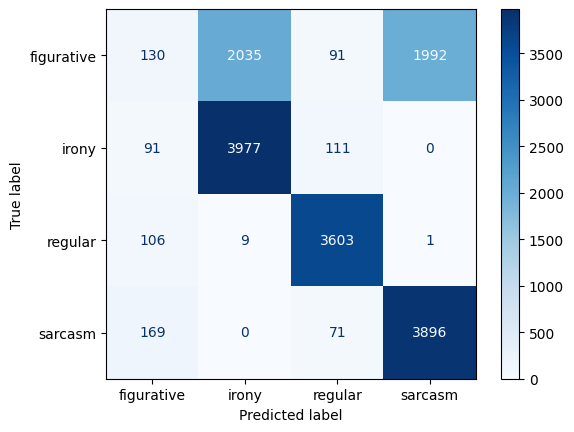

In [21]:
cm_nb = confusion_matrix(y_test, Pred_y_nb)
ConfusionMatrixDisplay(cm_nb, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()

Model 2: Random Forest

In [22]:
model_rf = RandomForestClassifier(class_weight='balanced', n_estimators = 3000)
model_rf.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",3000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [23]:
Pred_y_rf = model_rf.predict(X_test_matrix)
y_pred_proba_rf = model_rf.predict_proba(X_test_matrix)

In [24]:
print(classification_report(y_test, Pred_y_rf,
      target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

  figurative       0.07      0.05      0.06      4248
       irony       0.56      0.64      0.60      4179
     regular       0.96      0.99      0.97      3719
     sarcasm       0.60      0.71      0.65      4136

    accuracy                           0.58     16282
   macro avg       0.55      0.60      0.57     16282
weighted avg       0.54      0.58      0.56     16282



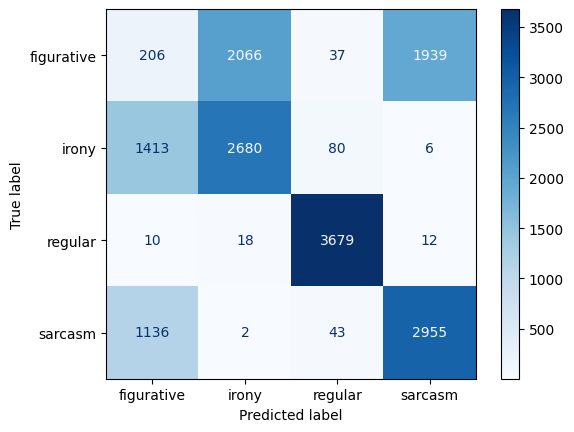

In [25]:
cm_rf = confusion_matrix(y_test, Pred_y_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()

Model 3: XGBoost

In [26]:
from xgboost import XGBClassifier

In [27]:
model_x = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    n_jobs=-1,
    eval_metric='logloss'
)
model_x.fit(X,y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [28]:
Pred_y_x = model_x.predict(X_test_matrix)
y_pred_proba_x = model_x.predict_proba(X_test_matrix)

In [29]:
print(classification_report(y_test, Pred_y_x,
      target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

  figurative       0.21      0.00      0.00      4248
       irony       0.66      0.97      0.78      4179
     regular       0.93      1.00      0.96      3719
     sarcasm       0.66      0.98      0.79      4136

    accuracy                           0.72     16282
   macro avg       0.61      0.74      0.63     16282
weighted avg       0.60      0.72      0.62     16282



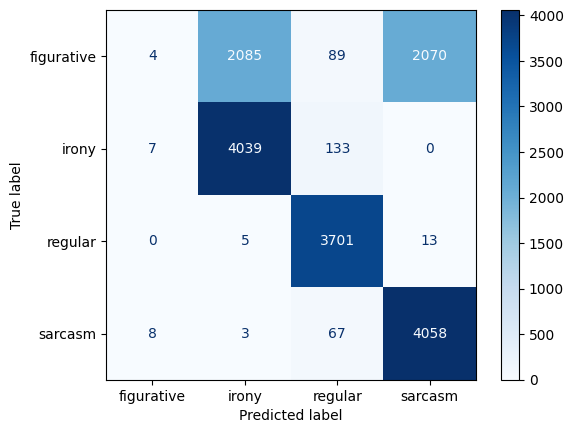

In [30]:
cm_x = confusion_matrix(y_test, Pred_y_x)
ConfusionMatrixDisplay(cm_x, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()

Model 4: Neural Nets

In [31]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(0)

In [54]:
def build_classifier():
    model = Sequential([
        Dense(128, activation='relu', input_shape=[X.shape[1]]),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(4, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [55]:
model_nn = build_classifier()
print(model_nn.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,132 (47.39 KB)

 Trainable params: 11,684 (45.64 KB)

 Non-trainable params: 448 (1.75 KB)

None


In [71]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    mode='min',            
    restore_best_weights=True
)

history = model_nn.fit(
    X, y,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 1s 745us/step - accuracy: 0.7276 - loss: 0.5527 - val_accuracy: 0.7248 - val_loss: 0.5459
Epoch 2/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 1s 896us/step - accuracy: 0.7275 - loss: 0.5534 - val_accuracy: 0.7246 - val_loss: 0.5454
Epoch 3/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 1s 671us/step - accuracy: 0.7275 - loss: 0.5532 - val_accuracy: 0.7249 - val_loss: 0.5464
Epoch 4/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 1s 680us/step - accuracy: 0.7275 - loss: 0.5526 - val_accuracy: 0.7226 - val_loss: 0.5535
Epoch 5/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step - accuracy: 0.7275 - loss: 0.5532 - val_accuracy: 0.7246 - val_loss: 0.5459
Epoch 6/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 1s 805us/step - accuracy: 0.7278 - loss: 0.5528 - val_accuracy: 0.7248 - val_loss: 0.5454
Epoch 7/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 1s 690us/step - accuracy: 0.7274 - loss: 0.5535 - val_accuracy: 0.7242 - val_loss: 0.5454
Epoch 8/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step - accuracy: 0.7276 - loss: 0

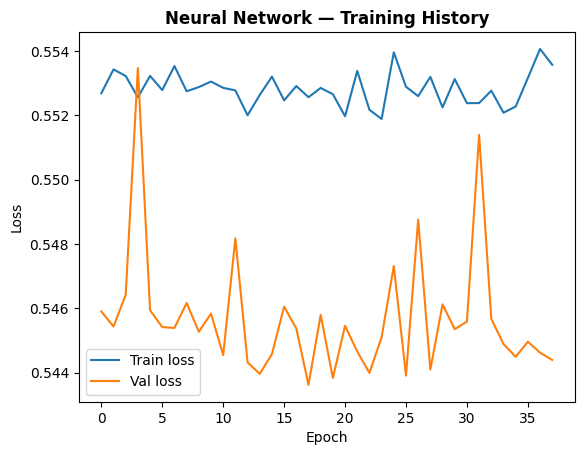

In [72]:

plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Neural Network — Training History', fontweight='bold')
plt.legend()
plt.show()

In [73]:
Pred_y_nn= model_nn.predict(X_test_matrix)

509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 230us/step


In [74]:
pred_nn = np.argmax(Pred_y_nn, axis=1)

print(classification_report(y_test, pred_nn, target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

  figurative       1.00      0.00      0.00      4248
       irony       0.66      0.97      0.78      4179
     regular       0.93      1.00      0.96      3719
     sarcasm       0.66      0.99      0.79      4136

    accuracy                           0.73     16282
   macro avg       0.81      0.74      0.63     16282
weighted avg       0.81      0.73      0.62     16282



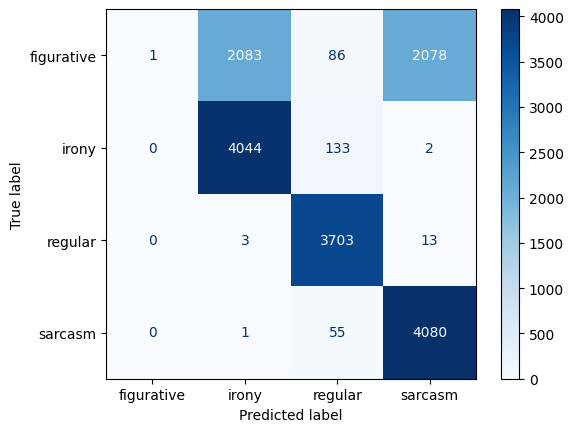

In [75]:
cmnn = confusion_matrix(y_test, pred_nn)
ConfusionMatrixDisplay(cmnn, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()


LSTMs

In [81]:
from tensorflow.keras.layers import LSTM, Embedding, SpatialDropout1D

def build_lstm(vocab_size, embedding_dim=64, max_len=50):
    model = Sequential([
        # maps token integers to dense vectors
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        
        # sequence modelling
        LSTM(128, return_sequences=True),
        Dropout(0.2),
        
        LSTM(64),
        Dropout(0.2),
        
        # classification head
        Dense(32, activation='relu'),
        Dense(4, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [83]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=50)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=50)

vocab_size = min(tokenizer.num_words, len(tokenizer.word_index) + 1)
model_lstm = build_lstm(vocab_size)
model_lstm.build(input_shape=(None, 50))  # None = batch size, 50 = max_len
print(model_lstm.summary())

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 50, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 50, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 790,436 (3.02 MB)

 Trainable params: 790,436 (3.02 MB)

 Non-trainable params: 0 (0.00 B)

None


In [84]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    mode='min',            
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train_seq, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.7043 - loss: 0.5868 - val_accuracy: 0.7360 - val_loss: 0.5002
Epoch 2/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.7388 - loss: 0.5031 - val_accuracy: 0.7361 - val_loss: 0.4987
Epoch 3/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.7391 - loss: 0.4987 - val_accuracy: 0.7360 - val_loss: 0.4990
Epoch 4/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.7402 - loss: 0.4945 - val_accuracy: 0.7355 - val_loss: 0.5019
Epoch 5/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.7485 - loss: 0.4816 - val_accuracy: 0.7087 - val_loss: 0.5208
Epoch 6/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.7625 - loss: 0.4633 - val_accuracy: 0.6823 - val_loss: 0.5621
Epoch 7/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.7812 - loss: 0.4427 - val_accuracy: 0.6733 - val_loss: 0.5915
Epoch 8/200
815/815 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.7964 - loss: 0

In [86]:
Pred_y_lstm= model_lstm.predict(X_test_seq)

509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step


In [87]:
pred_lstm = np.argmax(Pred_y_lstm, axis=1)

print(classification_report(y_test, pred_lstm, target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

  figurative       1.00      0.00      0.00      4248
       irony       0.66      1.00      0.79      4179
     regular       1.00      1.00      1.00      3719
     sarcasm       0.66      1.00      0.80      4136

    accuracy                           0.74     16282
   macro avg       0.83      0.75      0.65     16282
weighted avg       0.83      0.74      0.63     16282



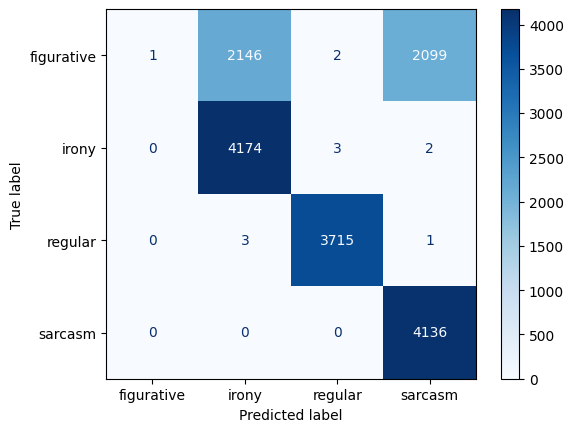

In [88]:
cmlstm = confusion_matrix(y_test, pred_lstm)
ConfusionMatrixDisplay(cmlstm, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()


AUC-ROC Curves

509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 225us/step
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step


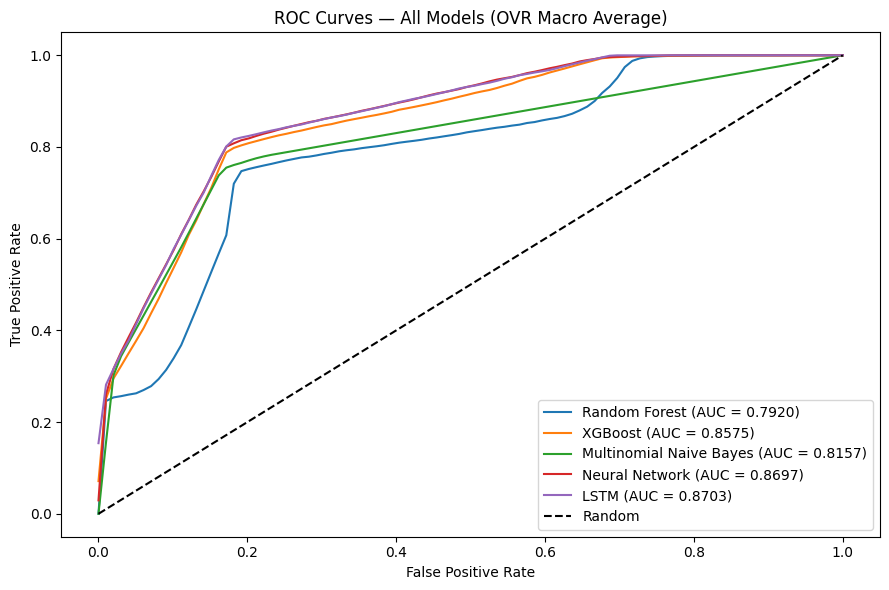

In [92]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_test, classes=[0,1,2,3])

models = {
    'Random Forest':           (model_rf,   X_test_matrix),
    'XGBoost':                 (model_x,    X_test_matrix),
    'Multinomial Naive Bayes': (MB,          X_test_matrix),
    'Neural Network':          (model_nn,    X_test_matrix),
    'LSTM':                    (model_lstm,  X_test_seq)
}

plt.figure(figsize=(9, 6))

for name, (model, X_feat) in models.items():
    proba = model.predict(X_feat) if isinstance(model, tf.keras.Model) \
            else model.predict_proba(X_feat)
    auc = roc_auc_score(y_test, proba, multi_class='ovr')
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros(100)
    for i in range(4):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr /= 4
    plt.plot(mean_fpr, mean_tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models (OVR Macro Average)')
plt.legend()
plt.tight_layout()
plt.show()

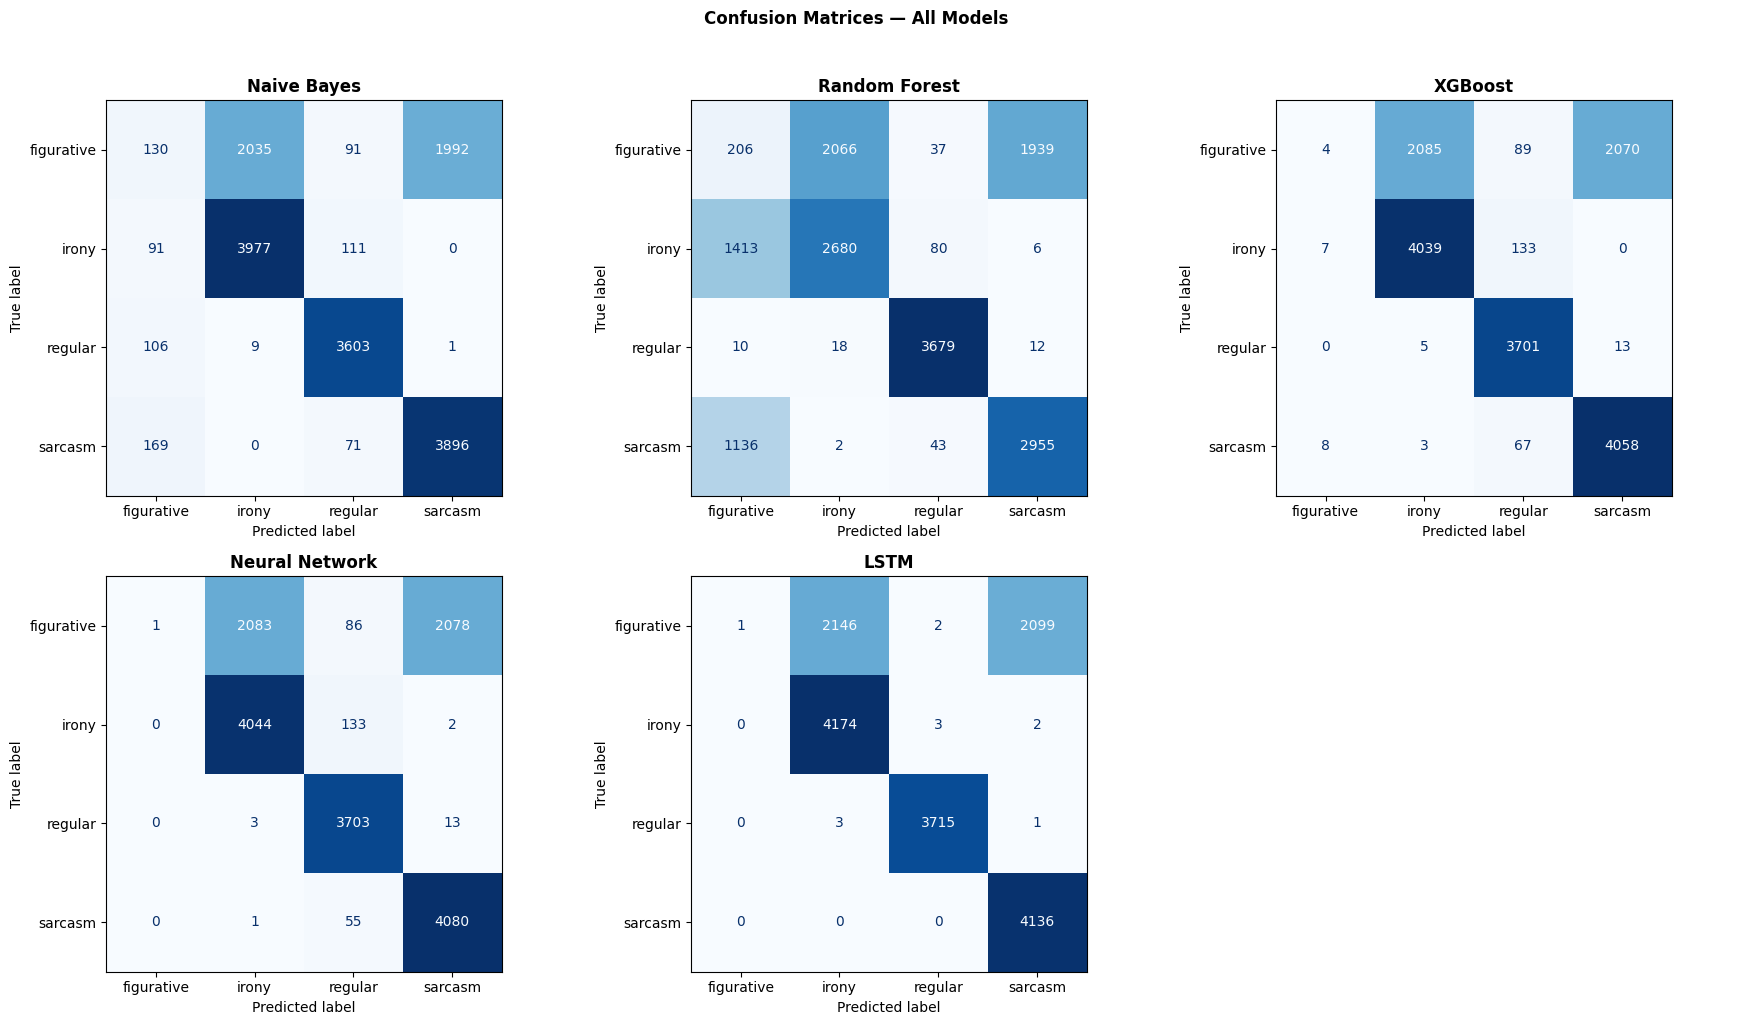

In [91]:
predictions = {
    'Naive Bayes':    Pred_y_nb,
    'Random Forest':  Pred_y_rf,
    'XGBoost':        Pred_y_x,
    'Neural Network': pred_nn,
    'LSTM':           pred_lstm
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_.astype(str)).plot(
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(name, fontweight='bold')

axes[-1].axis('off')  # hide the empty 6th subplot
plt.suptitle('Confusion Matrices — All Models', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()